# RepNet-SE: Neural ECG Classification for Preeclampsia Detection

**Architecture:** RepNet-SE Deep (4-stage per-lead CNN with SE blocks + cross-lead attention)  
**Parameters:** 65,748  
**Dataset:** 2,178 12-lead ECGs (335 PE+, 15.4% prevalence)  
**Evaluation:** 20 patient-grouped holdout splits, 5-bag averaging

In [28]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold

sys.path.insert(0, str(Path('..').resolve()))
from src.models.repnet_se import RepNetSE
from src.train_explorer_v2 import load_combined, preprocess_waveforms

LEAD_NAMES = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
RESULTS_DIR = Path('../cv_results/neural_final_2026-05-20_08-29-02')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 1. Classification Performance Distribution

In [29]:
with open(RESULTS_DIR / 'results.json') as f:
    results = json.load(f)

aurocs = np.array([r['metrics']['auroc'] for r in results])
auprcs = np.array([r['metrics']['auprc'] for r in results])
seeds = [r['seed'] for r in results]

sem = aurocs.std(ddof=1) / np.sqrt(len(aurocs))
print(f'RepNet-SE Deep (65,748 params, 5-bag, 20 splits)')
print(f'  AUROC: mean={aurocs.mean():.4f} +/- {aurocs.std(ddof=1):.4f}  median={np.median(aurocs):.4f}')
print(f'  95% CI: [{aurocs.mean()-1.96*sem:.4f}, {aurocs.mean()+1.96*sem:.4f}]')
print(f'  AUPRC: mean={auprcs.mean():.4f} +/- {auprcs.std(ddof=1):.4f}')
print(f'  Splits >= 0.70: {(aurocs >= 0.70).sum()}/20 ({100*(aurocs >= 0.70).mean():.0f}%)')

RepNet-SE Deep (65,748 params, 5-bag, 20 splits)
  AUROC: mean=0.6678 +/- 0.0664  median=0.6464
  95% CI: [0.6387, 0.6969]
  AUPRC: mean=0.2912 +/- 0.0602
  Splits >= 0.70: 7/20 (35%)


In [30]:
# Per-seed AUROC bar chart
sort_idx = np.argsort(aurocs)[::-1]
colors = ['#2ecc71' if a >= 0.70 else '#e74c3c' for a in aurocs[sort_idx]]

fig = go.Figure()
fig.add_trace(go.Bar(
    x=[str(seeds[i]) for i in sort_idx], y=aurocs[sort_idx],
    marker_color=colors, opacity=0.85,
))
fig.add_hline(y=0.70, line_dash='dash', line_color='red', annotation_text='Target 0.70')
fig.add_hline(y=aurocs.mean(), line_dash='dot', line_color='blue',
              annotation_text=f'Mean {aurocs.mean():.4f}')
fig.update_layout(
    title='RepNet-SE: Per-Seed Test AUROC (20 Holdout Splits)',
    xaxis_title='Seed', yaxis_title='Test AUROC',
    template='plotly_white', width=1000, height=450,
    yaxis_range=[0.4, 0.85],
)
fig.show()

In [31]:
# AUROC distribution histogram
fig = make_subplots(rows=1, cols=2, subplot_titles=['AUROC Distribution', 'AUPRC Distribution'])

fig.add_trace(go.Histogram(x=aurocs, nbinsx=12, marker_color='steelblue', opacity=0.8,
                            name='AUROC'), row=1, col=1)
fig.add_vline(x=aurocs.mean(), line_dash='dash', line_color='red', row=1, col=1)

fig.add_trace(go.Histogram(x=auprcs, nbinsx=12, marker_color='orange', opacity=0.8,
                            name='AUPRC'), row=1, col=2)
fig.add_vline(x=auprcs.mean(), line_dash='dash', line_color='red', row=1, col=2)

fig.update_layout(template='plotly_white', width=1000, height=400, showlegend=False,
                  title='Test Metric Distributions (20 Splits)')
fig.show()

## 2. Comparison: Neural vs LightGBM

In [32]:
# Load LightGBM final results for comparison
lgbm_dirs = sorted(Path('../cv_results').glob('final_*/results.json'))
if lgbm_dirs:
    with open(lgbm_dirs[-1]) as f:
        lgbm_data = json.load(f)
    lgbm_aurocs = np.array([r['metrics']['auroc'] for r in lgbm_data])
    
    fig = go.Figure()
    fig.add_trace(go.Box(y=aurocs, name='RepNet-SE (Neural)', marker_color='steelblue',
                         boxpoints='all', jitter=0.3, pointpos=-1.8))
    fig.add_trace(go.Box(y=lgbm_aurocs, name='5-Bag LightGBM', marker_color='orange',
                         boxpoints='all', jitter=0.3, pointpos=-1.8))
    fig.add_hline(y=0.70, line_dash='dash', line_color='red')
    fig.update_layout(
        title='Neural vs LightGBM: Test AUROC Distribution',
        yaxis_title='Test AUROC', template='plotly_white',
        width=700, height=500,
    )
    fig.show()
    
    print(f'RepNet-SE Neural: mean={aurocs.mean():.4f} +/- {aurocs.std(ddof=1):.4f}')
    print(f'5-Bag LightGBM:   mean={lgbm_aurocs.mean():.4f} +/- {lgbm_aurocs.std(ddof=1):.4f}')
else:
    print('No LightGBM results found')

RepNet-SE Neural: mean=0.6678 +/- 0.0664
5-Bag LightGBM:   mean=0.7446 +/- 0.0465


## 3. Load Best Model & Data

In [33]:
# Load the best-performing seed's model
best_seed = int(seeds[np.argmax(aurocs)])
print(f'Best seed: {best_seed} (AUROC={aurocs.max():.4f})')

ckpt = torch.load(RESULTS_DIR / 'weights' / f'best_seed_{best_seed}.pt',
                   map_location=DEVICE, weights_only=False)
model = RepNetSE(**ckpt['net_cfg']).to(DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Loaded model: {sum(p.numel() for p in model.parameters()):,} params')
print(f'Config: {ckpt["net_cfg"]}')

Best seed: 45 (AUROC=0.7870)
Loaded model: 65,748 params
Config: {'stage_filters': (16, 32, 48, 64), 'stage_kernels': (7, 5, 5, 3), 'ms_kernels': (5, 9, 15), 'dropout': 0.15, 'n_heads': 4, 'se_reduction': 4, 'attn_pool_hidden': 32}


In [34]:
# Load and preprocess data, recreate the same split
X_wave, X_feat, y, patient_ids, feat_cols = load_combined('../data/seniordesign_upload')
X_wave = preprocess_waveforms(X_wave)
print(f'Data: {X_wave.shape}, pos={int(y.sum())} ({100*y.mean():.1f}%)')

ss = np.random.SeedSequence(best_seed)
split_seed = int(ss.generate_state(1)[0])
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=split_seed)
dev_idx, test_idx = next(sgkf.split(np.zeros(len(y)), y, groups=patient_ids))

X_test = X_wave[test_idx]
y_test = y[test_idx]
print(f'Test set: N={len(y_test)}, pos={int(y_test.sum())} ({100*y_test.mean():.1f}%)')

Data: (2178, 12, 2500), pos=335 (15.4%)
Test set: N=436, pos=67 (15.4%)


In [35]:
# Get predictions
with torch.no_grad():
    x_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
    logits = model(x_t)
    probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

test_auroc = roc_auc_score(y_test, probs)
print(f'Test AUROC (single model): {test_auroc:.4f}')

Test AUROC (single model): 0.7564


## 4. Score Distribution (PE+ vs PE-)

In [36]:
fig = go.Figure()
fig.add_trace(go.Histogram(x=probs[y_test == 0], name='Normal (PE-)',
                            marker_color='steelblue', opacity=0.6, nbinsx=30))
fig.add_trace(go.Histogram(x=probs[y_test == 1], name='Preeclampsia (PE+)',
                            marker_color='red', opacity=0.6, nbinsx=30))
fig.update_layout(
    barmode='overlay',
    title=f'Predicted Probability Distribution (AUROC={test_auroc:.4f})',
    xaxis_title='P(Preeclampsia)', yaxis_title='Count',
    template='plotly_white', width=900, height=450,
)
fig.show()

In [37]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'RepNet-SE (AUC={test_auroc:.3f})',
                          line=dict(color='steelblue', width=2)))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Random',
                          line=dict(color='gray', dash='dash')))
fig.update_layout(
    title='ROC Curve', xaxis_title='False Positive Rate', yaxis_title='True Positive Rate',
    template='plotly_white', width=600, height=550,
)
fig.show()

## 5. Lead Attention Weights

The LeadAttentionPool learns which ECG leads are most informative for PE classification.

In [38]:
# Extract lead attention weights for all test samples
with torch.no_grad():
    _ = model(x_t)  # forward pass populates last_weights
    lead_weights = model.lead_pool.last_weights.cpu().numpy()  # (N_test, 12)

print(f'Lead weights shape: {lead_weights.shape}')

# Average lead attention by class
w_neg = lead_weights[y_test == 0].mean(axis=0)
w_pos = lead_weights[y_test == 1].mean(axis=0)
w_all = lead_weights.mean(axis=0)

fig = go.Figure()
fig.add_trace(go.Bar(x=LEAD_NAMES, y=w_neg, name='Normal (PE-)', marker_color='steelblue', opacity=0.8))
fig.add_trace(go.Bar(x=LEAD_NAMES, y=w_pos, name='Preeclampsia (PE+)', marker_color='red', opacity=0.8))
fig.update_layout(
    barmode='group',
    title='Lead Attention Weights by Class',
    xaxis_title='ECG Lead', yaxis_title='Attention Weight (softmax)',
    template='plotly_white', width=900, height=450,
)
fig.show()

print('\nMean lead attention weights:')
for i, name in enumerate(LEAD_NAMES):
    print(f'  {name:4s}: all={w_all[i]:.4f}  PE-={w_neg[i]:.4f}  PE+={w_pos[i]:.4f}  diff={w_pos[i]-w_neg[i]:+.4f}')

Lead weights shape: (436, 12)



Mean lead attention weights:
  I   : all=0.0815  PE-=0.0814  PE+=0.0820  diff=+0.0006
  II  : all=0.0804  PE-=0.0802  PE+=0.0815  diff=+0.0013
  III : all=0.0909  PE-=0.0919  PE+=0.0855  diff=-0.0064
  aVR : all=0.0777  PE-=0.0772  PE+=0.0807  diff=+0.0036
  aVL : all=0.0899  PE-=0.0905  PE+=0.0861  diff=-0.0044
  aVF : all=0.0846  PE-=0.0847  PE+=0.0841  diff=-0.0007
  V1  : all=0.0813  PE-=0.0813  PE+=0.0809  diff=-0.0005
  V2  : all=0.0858  PE-=0.0860  PE+=0.0848  diff=-0.0012
  V3  : all=0.0849  PE-=0.0849  PE+=0.0851  diff=+0.0002
  V4  : all=0.0823  PE-=0.0819  PE+=0.0845  diff=+0.0026
  V5  : all=0.0809  PE-=0.0804  PE+=0.0832  diff=+0.0028
  V6  : all=0.0798  PE-=0.0795  PE+=0.0817  diff=+0.0021


In [39]:
# Lead attention heatmap across samples
sort_by_prob = np.argsort(probs)
fig = go.Figure(data=go.Heatmap(
    z=lead_weights[sort_by_prob].T,
    x=list(range(len(sort_by_prob))),
    y=LEAD_NAMES,
    colorscale='Viridis',
    colorbar_title='Weight',
))
fig.update_layout(
    title='Lead Attention Weights (samples sorted by P(PE), low -> high)',
    xaxis_title='Samples (sorted by predicted PE probability)',
    yaxis_title='ECG Lead',
    template='plotly_white', width=1100, height=400,
)
fig.show()

## 6. Cross-Lead Attention Maps

Extracting attention weights from the multi-head self-attention across leads at each stage.

In [40]:
# Hook to capture cross-lead attention weights
attn_weights_store = {}

def make_attn_hook(name):
    def hook(module, input, output):
        # output = (attn_output, attn_weights) from nn.MultiheadAttention
        _, weights = output
        if weights is not None:
            attn_weights_store[name] = weights.detach().cpu().numpy()
    return hook

# Register hooks on each stage's attention module
hooks = []
hooks.append(model.stage1_attn.attn.register_forward_hook(make_attn_hook('stage1')))
for i, stage in enumerate(model.later_stages):
    hooks.append(stage['attn'].attn.register_forward_hook(make_attn_hook(f'stage{i+2}')))

# Forward pass to capture attention
with torch.no_grad():
    _ = model(x_t[:50])  # use first 50 samples

# Remove hooks
for h in hooks:
    h.remove()

print('Captured attention weights:')
for name, w in attn_weights_store.items():
    print(f'  {name}: shape={w.shape}')

Captured attention weights:
  stage1: shape=(50, 12, 12)
  stage2: shape=(50, 12, 12)
  stage3: shape=(50, 12, 12)
  stage4: shape=(50, 12, 12)


In [41]:
# Visualize average cross-lead attention at each stage
n_stages = len(attn_weights_store)
fig = make_subplots(rows=1, cols=n_stages,
                    subplot_titles=[f'Stage {i+1} Attention' for i in range(n_stages)])

for i, (name, weights) in enumerate(attn_weights_store.items()):
    avg_w = weights.mean(axis=0)  # average over batch
    if avg_w.shape[0] == 12 and avg_w.shape[1] == 12:
        fig.add_trace(go.Heatmap(
            z=avg_w, x=LEAD_NAMES, y=LEAD_NAMES,
            colorscale='Blues', showscale=(i == n_stages - 1),
        ), row=1, col=i+1)

fig.update_layout(
    title='Cross-Lead Attention (averaged over 50 samples)',
    template='plotly_white', width=350*n_stages, height=400,
)
fig.show()

In [42]:
# Cross-lead attention difference: PE+ vs PE-
# Re-run for PE+ and PE- separately
attn_by_class = {}
for label, label_name in [(0, 'PE-'), (1, 'PE+')]:
    mask = y_test[:50] == label
    if mask.sum() == 0:
        continue
    x_sub = x_t[:50][mask]
    attn_weights_store.clear()
    
    hooks = []
    hooks.append(model.stage1_attn.attn.register_forward_hook(make_attn_hook('stage1')))
    for i, stage in enumerate(model.later_stages):
        hooks.append(stage['attn'].attn.register_forward_hook(make_attn_hook(f'stage{i+2}')))
    with torch.no_grad():
        _ = model(x_sub)
    for h in hooks:
        h.remove()
    attn_by_class[label_name] = {k: v.mean(axis=0) for k, v in attn_weights_store.items()}

# Show Stage 3 (deepest) attention difference
if 'PE+' in attn_by_class and 'PE-' in attn_by_class and 'stage3' in attn_by_class['PE+']:
    diff = attn_by_class['PE+']['stage3'] - attn_by_class['PE-']['stage3']
    fig = go.Figure(data=go.Heatmap(
        z=diff, x=LEAD_NAMES, y=LEAD_NAMES,
        colorscale='RdBu_r', zmid=0,
    ))
    fig.update_layout(
        title='Stage 3 Cross-Lead Attention Difference (PE+ minus PE-)',
        template='plotly_white', width=600, height=500,
    )
    fig.show()

## 7. Saliency Maps (Gradient-Based)

Input-gradient saliency shows which time points and leads the model is most sensitive to.

In [43]:
def compute_saliency(model, x, target_class=1):
    """Compute gradient-based saliency map."""
    x_in = x.clone().detach().requires_grad_(True)
    model.zero_grad()
    logits = model(x_in)
    score = logits[:, target_class].sum()
    score.backward()
    saliency = x_in.grad.abs().cpu().numpy()  # (N, 12, T)
    return saliency

# Compute saliency for test samples
model.eval()
n_samples = min(100, len(X_test))
x_sal = torch.tensor(X_test[:n_samples], dtype=torch.float32).to(DEVICE)
saliency = compute_saliency(model, x_sal)
print(f'Saliency shape: {saliency.shape}')

# Average saliency by class
sal_neg = saliency[y_test[:n_samples] == 0].mean(axis=0)  # (12, 2500)
sal_pos = saliency[y_test[:n_samples] == 1].mean(axis=0)  # (12, 2500)
print(f'PE- samples: {(y_test[:n_samples] == 0).sum()}')
print(f'PE+ samples: {(y_test[:n_samples] == 1).sum()}')

Saliency shape: (100, 12, 2500)
PE- samples: 100
PE+ samples: 0


C:\Users\email\AppData\Local\Temp\ipykernel_7012\728746062.py:20: RuntimeWarning: Mean of empty slice
  sal_pos = saliency[y_test[:n_samples] == 1].mean(axis=0)  # (12, 2500)
C:\Users\email\PycharmProjects\repnet\.venv\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [44]:
# Saliency heatmap: leads x time
time_axis = np.arange(2500) / 250.0  # seconds

fig = make_subplots(rows=2, cols=1, subplot_titles=['Normal (PE-)', 'Preeclampsia (PE+)'],
                    shared_xaxes=True, vertical_spacing=0.08)

fig.add_trace(go.Heatmap(
    z=sal_neg, x=time_axis, y=LEAD_NAMES,
    colorscale='Hot', colorbar=dict(title='Saliency', x=1.02, len=0.45, y=0.78),
), row=1, col=1)

fig.add_trace(go.Heatmap(
    z=sal_pos, x=time_axis, y=LEAD_NAMES,
    colorscale='Hot', colorbar=dict(title='Saliency', x=1.02, len=0.45, y=0.22),
), row=2, col=1)

fig.update_layout(
    title='Average Gradient Saliency Maps by Class',
    template='plotly_white', width=1200, height=600,
)
fig.update_xaxes(title_text='Time (seconds)', row=2, col=1)
fig.show()

In [45]:
# Per-lead saliency comparison
lead_sal_neg = sal_neg.mean(axis=1)  # (12,)
lead_sal_pos = sal_pos.mean(axis=1)  # (12,)

fig = go.Figure()
fig.add_trace(go.Bar(x=LEAD_NAMES, y=lead_sal_neg, name='Normal (PE-)',
                      marker_color='steelblue', opacity=0.8))
fig.add_trace(go.Bar(x=LEAD_NAMES, y=lead_sal_pos, name='Preeclampsia (PE+)',
                      marker_color='red', opacity=0.8))
fig.update_layout(
    barmode='group',
    title='Average Saliency per Lead by Class',
    xaxis_title='ECG Lead', yaxis_title='Mean |Gradient|',
    template='plotly_white', width=900, height=450,
)
fig.show()

In [ ]:
# Single-sample saliency overlay on ECG waveform
# Pick a high-confidence PE+ prediction
pe_mask = y_test[:n_samples] == 1
pe_probs = probs[:n_samples][pe_mask]
pe_indices = np.where(pe_mask)[0]
if len(pe_indices) > 0:
    best_pe_idx = pe_indices[np.argmax(pe_probs)]

    fig = make_subplots(rows=12, cols=1, shared_xaxes=True, vertical_spacing=0.005,
                        subplot_titles=[f'{name}' for name in LEAD_NAMES])

    ecg = X_test[best_pe_idx]  # (12, 2500)
    sal = saliency[best_pe_idx]  # (12, 2500)
    eps = 0.02 * sal.max()
    sal_log = np.log1p(sal / eps) / np.log1p(sal.max() / eps)  # log-normalized [0, 1]

    for i, name in enumerate(LEAD_NAMES):
        fig.add_trace(go.Scatter(
            x=time_axis, y=ecg[i], mode='lines', name=name,
            line=dict(color='gray', width=0.8), showlegend=False,
        ), row=i+1, col=1)

        fig.add_trace(go.Scatter(
            x=time_axis, y=ecg[i], mode='markers', name=f'{name} saliency',
            marker=dict(size=2, color=sal_log[i], colorscale='Hot',
                       showscale=(i == 0), cmin=0, cmax=1),
            showlegend=False,
        ), row=i+1, col=1)

    fig.update_layout(
        title=f'ECG with Log-Saliency Overlay (PE+ sample, P(PE)={probs[best_pe_idx]:.3f})',
        template='plotly_white', width=1200, height=1400,
        showlegend=False,
    )
    fig.show()

## 8. SE Block Channel Importance

Squeeze-and-Excitation blocks learn channel-wise recalibration weights.

In [47]:
# Hook SE blocks to capture channel weights
se_weights_store = {}

def make_se_hook(name):
    def hook(module, input, output):
        x = input[0]  # (N, C, T)
        w = x.mean(dim=-1)  # (N, C)
        w = module.fc(w)    # (N, C) after sigmoid
        se_weights_store[name] = w.detach().cpu().numpy()
    return hook

hooks = []
hooks.append(model.stage1_conv.se.register_forward_hook(make_se_hook('stage1')))
for i, stage in enumerate(model.later_stages):
    hooks.append(stage['conv'].se.register_forward_hook(make_se_hook(f'stage{i+2}')))

with torch.no_grad():
    _ = model(x_t[:50])

for h in hooks:
    h.remove()

# Visualize SE channel weights per stage
n_se = len(se_weights_store)
fig = make_subplots(rows=1, cols=n_se,
                    subplot_titles=[f'Stage {i+1} SE Weights ({v.shape[1]} ch)'
                                   for i, (k, v) in enumerate(se_weights_store.items())])

for i, (name, weights) in enumerate(se_weights_store.items()):
    avg_w = weights.mean(axis=0)  # average over batch*leads
    fig.add_trace(go.Bar(
        x=list(range(len(avg_w))), y=avg_w,
        marker_color='teal', opacity=0.8, showlegend=False,
    ), row=1, col=i+1)
    fig.update_yaxes(range=[0, 1], row=1, col=i+1)

fig.update_layout(
    title='SE Channel Importance per Stage (sigmoid weights, avg over samples)',
    template='plotly_white', width=350*n_se, height=350,
)
fig.show()

## 9. Architecture Summary

| Component | Details |
|-----------|--------|
| **Input** | 12-lead ECG, 2500 samples @ 250 Hz (10 sec) |
| **Stage 1** | Multi-scale DSConv (k=5,9,15) + SE(16) + CrossLeadAttn |
| **Stage 2** | DSConv(16->32, k=5) + SE(32) + CrossLeadAttn |
| **Stage 3** | DSConv(32->48, k=5) + SE(48) + CrossLeadAttn |
| **Stage 4** | DSConv(48->64, k=3) + SE(64) + CrossLeadAttn |
| **Fusion** | LeadAttentionPool -> Dropout(0.15) -> Linear(64,2) |
| **Params** | 65,748 |
| **Training** | AdamW, lr=2e-3, cosine LR, mixup(0.2), label smooth(0.05) |
| **Augmentation** | 7 ECG-specific transforms (noise, amp, shift, lead drop, cutout, wander, resample) |
| **Evaluation** | 20 patient-grouped holdout splits, 5-bag averaging |

## 10. Saliency Maps on ECG Waveforms

**Integrated Gradients** — accumulates gradients along the path from a zero baseline to the actual input, giving smooth, faithful per-sample attribution. Combined with **Grad-CAM** at the last convolutional stage for a complementary coarse spatial view.

Red = regions pushing toward PE+ prediction, Blue = regions pushing toward Normal.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from scipy.ndimage import gaussian_filter1d


def integrated_gradients(model, x_np, target_class=1, n_steps=50, smooth_sigma=5.0):
    """Integrated Gradients: accumulate gradients along interpolation path."""
    x = torch.tensor(x_np, dtype=torch.float32, device=DEVICE)
    baseline = torch.zeros_like(x)
    alphas = torch.linspace(0.5 / n_steps, 1.0 - 0.5 / n_steps, n_steps, device=DEVICE)
    interp = baseline.unsqueeze(0) + alphas.view(-1, 1, 1) * (x - baseline).unsqueeze(0)
    interp.requires_grad_(True)
    model.zero_grad()
    logits = model(interp)
    grads = torch.autograd.grad(logits[:, target_class].sum(), interp)[0]
    avg_grad = grads.mean(dim=0)
    attr = ((x - baseline) * avg_grad).cpu().numpy()
    if smooth_sigma > 0:
        attr = gaussian_filter1d(attr, sigma=smooth_sigma, axis=-1)
    return attr


def gradcam_per_lead(model, x_np, target_class=1, smooth_sigma=2.0):
    """Grad-CAM at the last convolutional stage, per lead."""
    x = torch.tensor(x_np, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    activations = {}

    def fwd_hook(_m, _i, o):
        activations['feat'] = o
        o.retain_grad()

    h = model.later_stages[-1]['conv'].register_forward_hook(fwd_hook)
    model.zero_grad()
    logits = model(x)
    logits[0, target_class].backward()
    h.remove()

    feat = activations['feat']       # (1, 12, C, T')
    grad = feat.grad                  # (1, 12, C, T')
    weights = grad.mean(dim=-1, keepdim=True)  # (1, 12, C, 1)
    cam = F.relu((weights * feat).sum(dim=2))  # (1, 12, T')
    cam = F.interpolate(cam.view(1, 12, -1), size=x_np.shape[-1],
                        mode='linear', align_corners=False)
    cam = cam.squeeze(0).detach().cpu().numpy()
    if smooth_sigma > 0:
        cam = gaussian_filter1d(cam, sigma=smooth_sigma, axis=-1)
    return cam


def combined_saliency(model, x_np, target_class=1):
    """Average of normalized IG and Grad-CAM for robust attribution."""
    ig = integrated_gradients(model, x_np, target_class=target_class)
    gc = gradcam_per_lead(model, x_np, target_class=target_class)
    ig_n = ig / (np.abs(ig).max() or 1.0)
    gc_n = gc / (np.abs(gc).max() or 1.0)
    return 0.5 * (ig_n + gc_n), ig, gc


def log_scale_attr(a, eps=0.02):
    """Compress dynamic range so subtle regions remain visible."""
    sign = np.sign(a)
    mag = np.abs(a)
    return sign * np.log1p(mag / eps) / np.log1p(1.0 / eps)


def plot_saliency_ecg(ecg, attr, prob, title, lead_names=LEAD_NAMES, fs=250.0):
    """12-lead ECG with log-scaled saliency heatmap overlay (12 rows x 1 col)."""
    t = np.arange(ecg.shape[1]) / fs
    attr_log = log_scale_attr(attr / (np.abs(attr).max() or 1.0))
    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    fig, axes = plt.subplots(12, 1, figsize=(14, 14),
                             gridspec_kw={'hspace': 0.08,
                                          'top': 0.94, 'bottom': 0.04,
                                          'left': 0.05, 'right': 0.92})
    for i, name in enumerate(lead_names):
        ax = axes[i]
        ax.imshow(attr_log[i][np.newaxis, :], aspect='auto', cmap='RdBu_r',
                  norm=norm, extent=[0, t[-1], -2.5, 2.5], alpha=0.65,
                  interpolation='bilinear')
        ax.plot(t, ecg[i], 'k-', linewidth=0.5)
        ax.set_xlim(0, t[-1])
        ax.set_ylim(-2.5, 2.5)
        ax.set_yticks([])
        ax.set_ylabel(name, fontsize=8, fontweight='bold', rotation=0,
                      labelpad=14, va='center')
        if i < 11:
            ax.set_xticks([])
        else:
            ax.set_xlabel('Time (s)', fontsize=7)
            ax.tick_params(labelsize=6)

    fig.suptitle(title, fontsize=10, fontweight='bold')
    sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, location='right', fraction=0.015, pad=0.02)
    cbar.set_label('Attribution (Red→PE+, Blue→Normal)', fontsize=7)
    cbar.ax.tick_params(labelsize=6)
    plt.show()


print('Saliency functions defined.')

In [49]:
# Select representative cases: confident TP, FP, and FN
pred = (probs >= 0.5).astype(int)

tp_mask = (y_test == 1) & (pred == 1)
fp_mask = (y_test == 0) & (pred == 1)
fn_mask = (y_test == 1) & (pred == 0)
tn_mask = (y_test == 0) & (pred == 0)

cases = {}
if tp_mask.any():
    idx = np.where(tp_mask)[0][np.argmax(probs[tp_mask])]
    cases['True Positive'] = idx
    print(f'Confident TP: idx={idx}, P(PE)={probs[idx]:.3f}')

if fp_mask.any():
    idx = np.where(fp_mask)[0][np.argmax(probs[fp_mask])]
    cases['False Positive'] = idx
    print(f'Confident FP: idx={idx}, P(PE)={probs[idx]:.3f}')

if fn_mask.any():
    idx = np.where(fn_mask)[0][np.argmin(probs[fn_mask])]
    cases['False Negative'] = idx
    print(f'Confident FN: idx={idx}, P(PE)={probs[idx]:.3f}')

print(f'\nConfusion: TP={tp_mask.sum()}, FP={fp_mask.sum()}, FN={fn_mask.sum()}, TN={tn_mask.sum()}')

Confident TP: idx=404, P(PE)=0.867
Confident FP: idx=21, P(PE)=0.854
Confident FN: idx=406, P(PE)=0.089

Confusion: TP=60, FP=205, FN=7, TN=164



Computing saliency for True Positive (idx=404)...


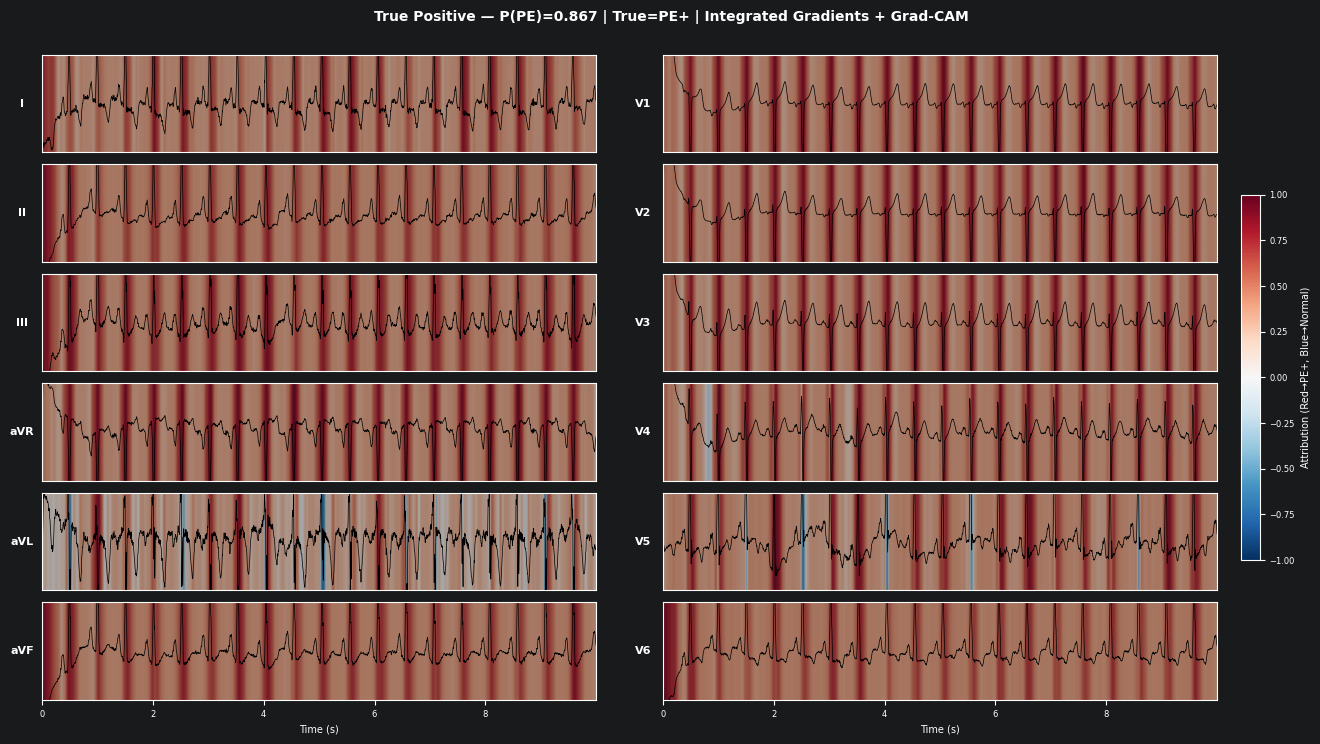


Computing saliency for False Positive (idx=21)...


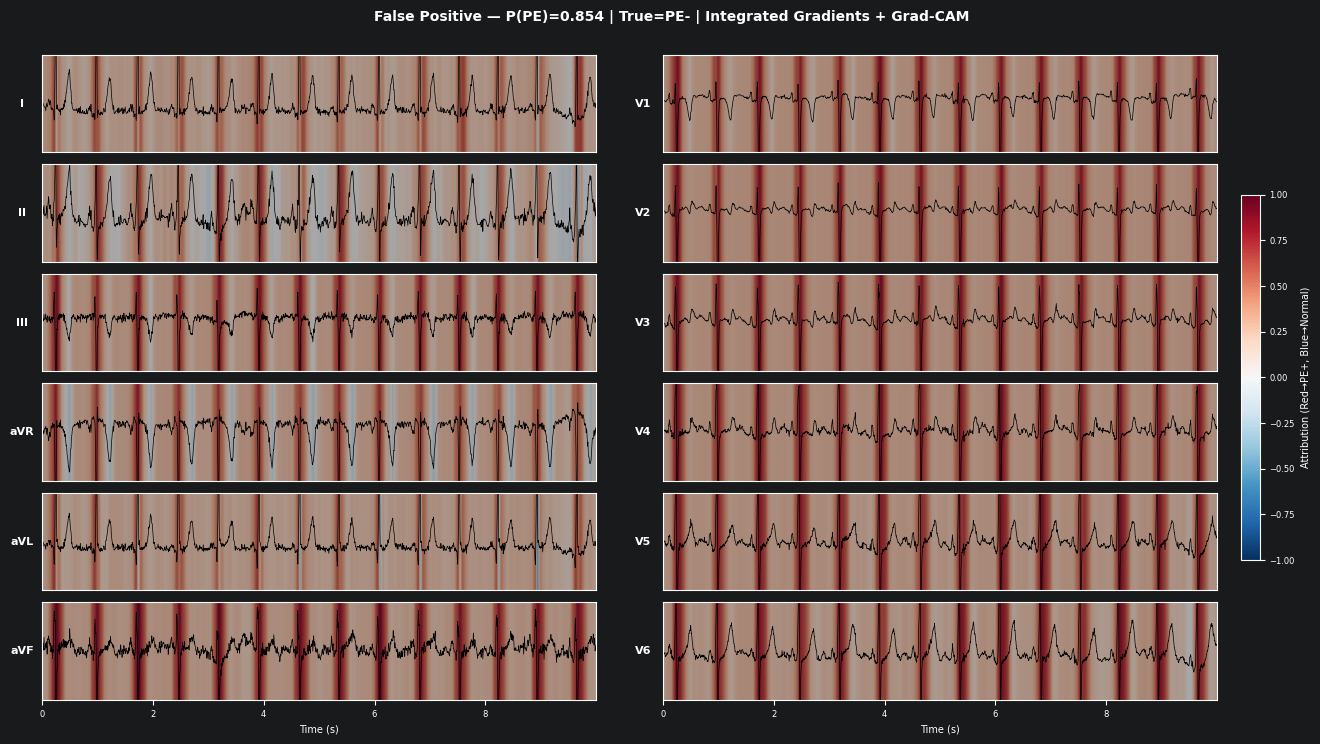


Computing saliency for False Negative (idx=406)...


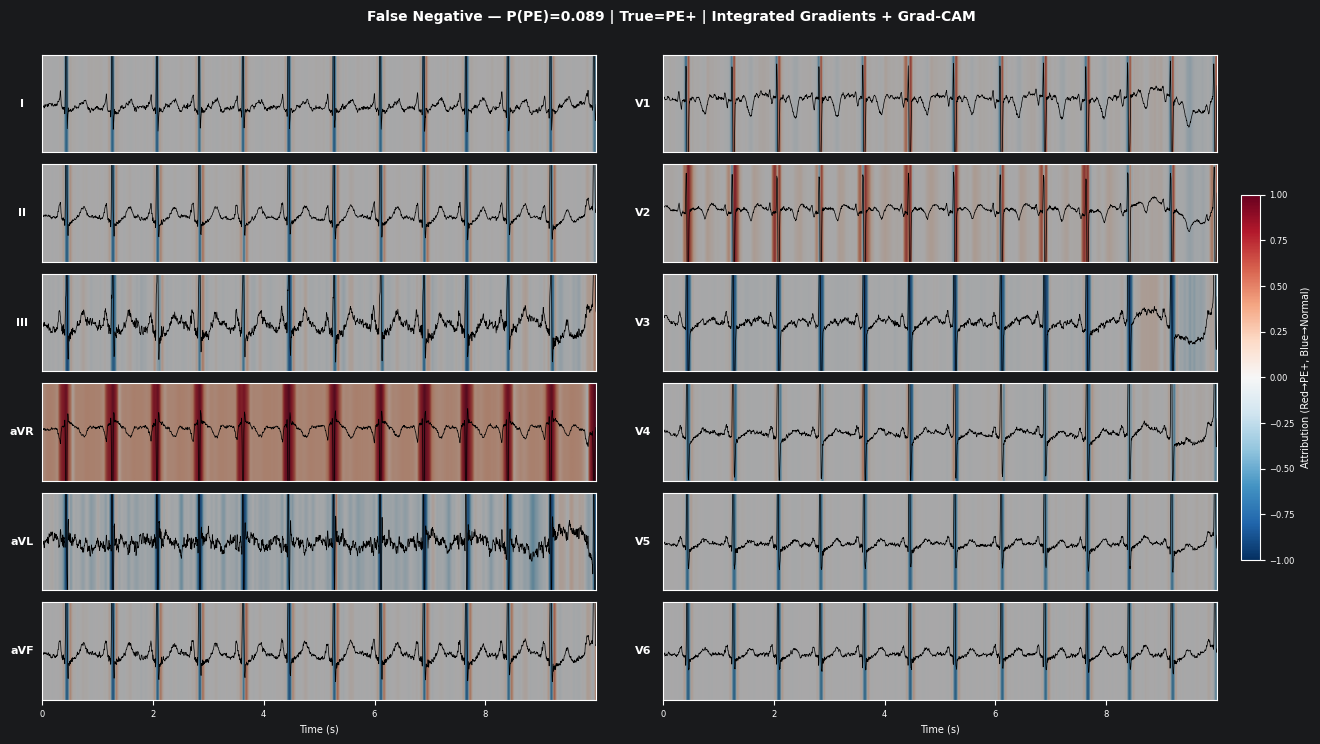

In [50]:
# Compute and plot saliency for each case
model.eval()
for case_name, idx in cases.items():
    print(f'\nComputing saliency for {case_name} (idx={idx})...')
    attr, ig_raw, gc_raw = combined_saliency(model, X_test[idx])
    label = 'PE+' if y_test[idx] == 1 else 'PE-'
    title = (f'{case_name} — P(PE)={probs[idx]:.3f} | '
             f'True={label} | Integrated Gradients + Grad-CAM')
    plot_saliency_ecg(X_test[idx], attr, probs[idx], title)

### 10b. Class-Averaged Temporal Saliency

Average IG attribution across all PE+ vs PE- test samples to see where the model consistently looks.

In [51]:
# Class-averaged Integrated Gradients across all test samples
print('Computing IG for all test samples (may take a minute)...')
ig_all = []
for i in range(len(X_test)):
    ig_i = integrated_gradients(model, X_test[i], target_class=1, n_steps=32, smooth_sigma=5.0)
    ig_all.append(ig_i)
    if (i + 1) % 50 == 0:
        print(f'  {i + 1}/{len(X_test)}')

ig_all = np.array(ig_all)  # (N_test, 12, 2500)
ig_pos = ig_all[y_test == 1].mean(axis=0)  # (12, 2500)
ig_neg = ig_all[y_test == 0].mean(axis=0)  # (12, 2500)
print(f'Done. PE+ samples: {(y_test == 1).sum()}, PE- samples: {(y_test == 0).sum()}')

Computing IG for all test samples (may take a minute)...
  50/436
  100/436
  150/436
  200/436
  250/436
  300/436
  350/436
  400/436
Done. PE+ samples: 67, PE- samples: 369


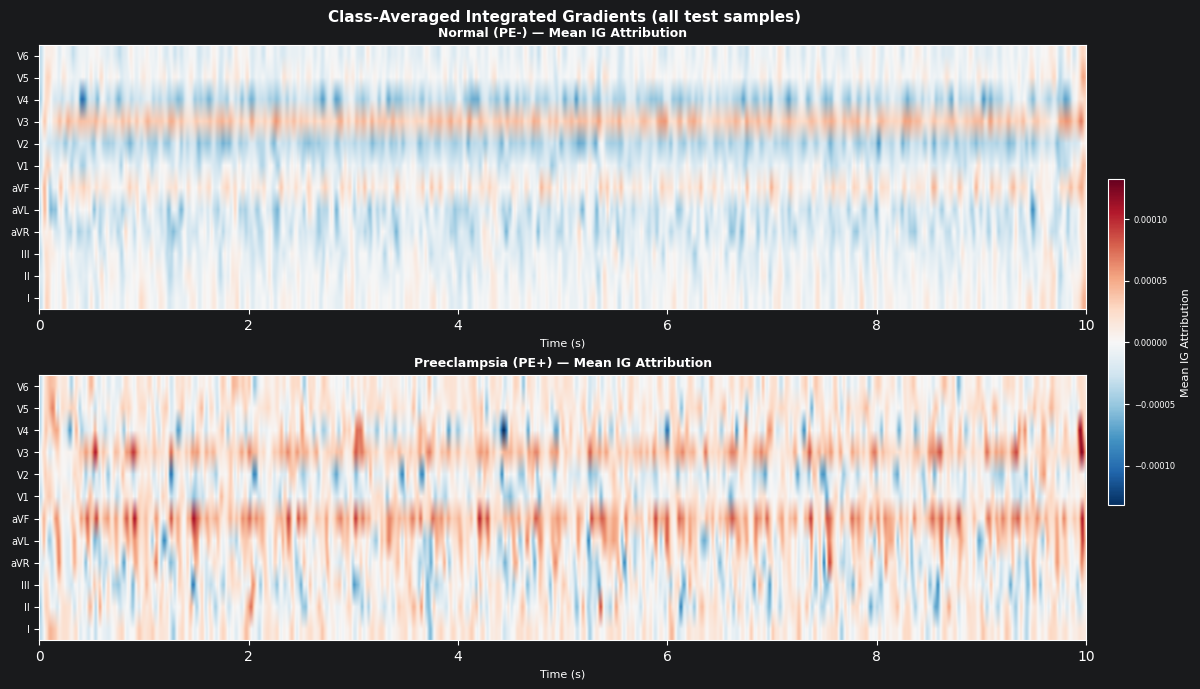

In [52]:
# Class-averaged IG heatmaps side by side
t = np.arange(2500) / 250.0

fig, axes = plt.subplots(2, 1, figsize=(14, 7),
                         gridspec_kw={'hspace': 0.25, 'top': 0.93, 'bottom': 0.08})

vmax = max(np.abs(ig_pos).max(), np.abs(ig_neg).max())
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

im0 = axes[0].imshow(ig_neg, aspect='auto', cmap='RdBu_r', norm=norm,
                      extent=[0, 10, -0.5, 11.5], interpolation='bilinear')
axes[0].set_yticks(range(12))
axes[0].set_yticklabels(LEAD_NAMES, fontsize=7)
axes[0].set_title('Normal (PE-) — Mean IG Attribution', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Time (s)', fontsize=8)

im1 = axes[1].imshow(ig_pos, aspect='auto', cmap='RdBu_r', norm=norm,
                      extent=[0, 10, -0.5, 11.5], interpolation='bilinear')
axes[1].set_yticks(range(12))
axes[1].set_yticklabels(LEAD_NAMES, fontsize=7)
axes[1].set_title('Preeclampsia (PE+) — Mean IG Attribution', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Time (s)', fontsize=8)

cbar = fig.colorbar(im1, ax=axes, location='right', fraction=0.015, pad=0.02)
cbar.set_label('Mean IG Attribution', fontsize=8)
cbar.ax.tick_params(labelsize=6)

fig.suptitle('Class-Averaged Integrated Gradients (all test samples)', fontsize=11, fontweight='bold')
plt.show()

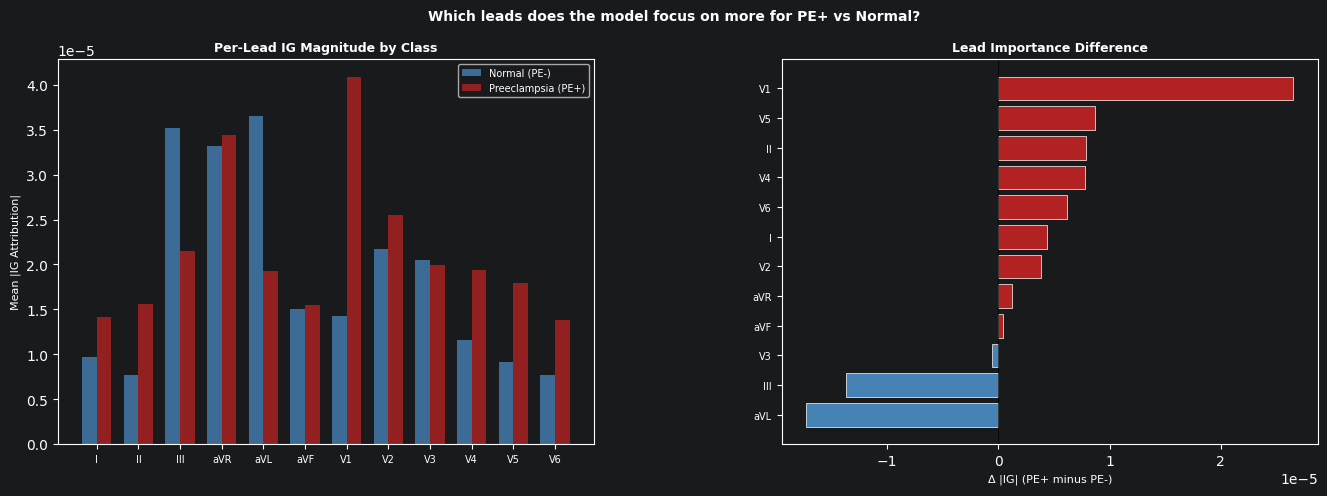

In [53]:
# Per-lead IG magnitude comparison: PE+ vs PE-
lead_ig_pos = np.abs(ig_pos).mean(axis=1)  # (12,)
lead_ig_neg = np.abs(ig_neg).mean(axis=1)  # (12,)
diff = lead_ig_pos - lead_ig_neg

fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         gridspec_kw={'wspace': 0.35, 'left': 0.06, 'right': 0.96})

# Per-lead IG by class
x_pos = np.arange(12)
w = 0.35
axes[0].bar(x_pos - w/2, lead_ig_neg, w, label='Normal (PE-)', color='steelblue', alpha=0.8)
axes[0].bar(x_pos + w/2, lead_ig_pos, w, label='Preeclampsia (PE+)', color='firebrick', alpha=0.8)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(LEAD_NAMES, fontsize=7)
axes[0].set_ylabel('Mean |IG Attribution|', fontsize=8)
axes[0].set_title('Per-Lead IG Magnitude by Class', fontsize=9, fontweight='bold')
axes[0].legend(fontsize=7)

# Difference (PE+ - PE-) sorted
order = np.argsort(diff)
colors = ['firebrick' if d > 0 else 'steelblue' for d in diff[order]]
axes[1].barh(range(12), diff[order], color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_yticks(range(12))
axes[1].set_yticklabels([LEAD_NAMES[i] for i in order], fontsize=7)
axes[1].set_xlabel('Δ |IG| (PE+ minus PE-)', fontsize=8)
axes[1].set_title('Lead Importance Difference', fontsize=9, fontweight='bold')
axes[1].axvline(0, color='black', linewidth=0.5)

plt.suptitle('Which leads does the model focus on more for PE+ vs Normal?',
             fontsize=10, fontweight='bold')
plt.show()

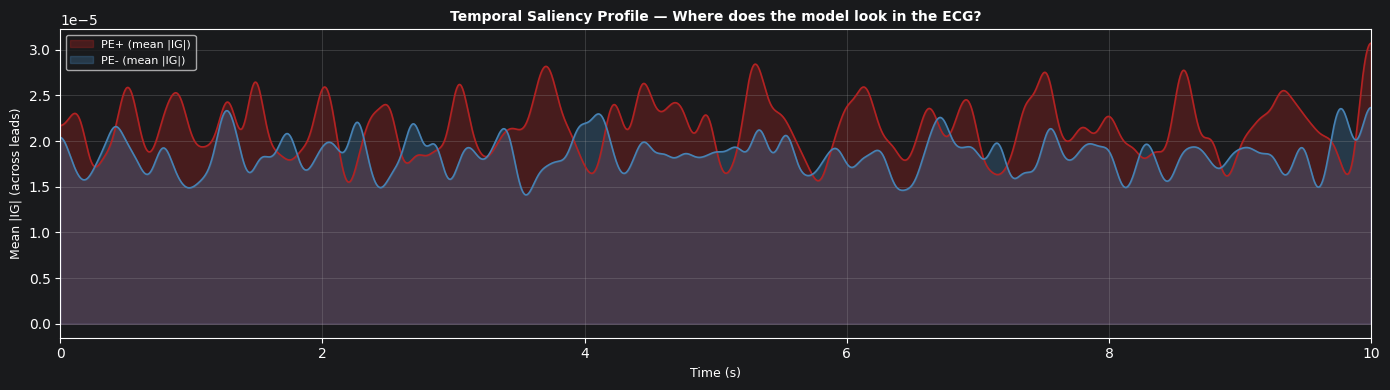

In [54]:
# Temporal saliency profile: aggregate across leads, compare PE+ vs PE- over time
# Shows WHERE in the 10-second window the model focuses (cardiac cycle phase)
temporal_pos = np.abs(ig_pos).mean(axis=0)  # (2500,) - mean across 12 leads
temporal_neg = np.abs(ig_neg).mean(axis=0)

# Smooth for clarity
temporal_pos_s = gaussian_filter1d(temporal_pos, sigma=15)
temporal_neg_s = gaussian_filter1d(temporal_neg, sigma=15)

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(t, temporal_pos_s, alpha=0.3, color='firebrick', label='PE+ (mean |IG|)')
ax.fill_between(t, temporal_neg_s, alpha=0.3, color='steelblue', label='PE- (mean |IG|)')
ax.plot(t, temporal_pos_s, color='firebrick', linewidth=1.2)
ax.plot(t, temporal_neg_s, color='steelblue', linewidth=1.2)
ax.set_xlabel('Time (s)', fontsize=9)
ax.set_ylabel('Mean |IG| (across leads)', fontsize=9)
ax.set_title('Temporal Saliency Profile — Where does the model look in the ECG?',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.set_xlim(0, 10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()